# 1. OpenAI VLM (GPT) - Basics
This section demonstrates the basic usage of OpenAI's Vision Language Model (VLM) capabilities using GPT-4.1.
We will use the OpenAI API to analyze an image and provide detailed textual insights.

**Reference Material**

- https://developers.openai.com/api/docs/quickstart?language=python
- https://platform.openai.com/docs/guides/text
- https://platform.openai.com/docs/guides/images-vision?api-mode=chat
- https://platform.openai.com/docs/guides/structured-outputs

In [1]:
from openai import OpenAI
from dotenv import load_dotenv  
import base64
import textwrap

# Function to encode the image
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')


load_dotenv()

openai_client = OpenAI()

In [3]:
# Basic call to GPT with a prompt and an image
# Example from: https://developers.openai.com/api/docs/quickstart/?lang=python

response = openai_client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "What teams are playing in this image?",
                },
                {
                    "type": "input_image",
                    "image_url": "https://api.nga.gov/iiif/a2e6da57-3cd1-4235-b20e-95dcaefed6c8/full/!800,800/0/default.jpg"
                }
            ]
        }
    ]
)

print(response.output_text)

This image does not depict a sports event or teams playing. It is a painting of a woman seated on a chair, wearing a striped blouse and a skirt with a polka dot pattern, holding a flower. There are no teams or sports elements visible in this artwork.


In [4]:
# Path to your image
img = "images/street_scene.jpg"

response = openai_client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "What's in this image?"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                }
            ],
        }
    ],
)

print(textwrap.fill(response.output_text, width=120))

The image depicts a lively urban street scene with various activities and people. In the foreground, there are two
people sitting on a bench, one reading a newspaper and the other an older man looking thoughtful. Near them, a person is
sitting on the ground using a tablet, and another person is lying down with eyes closed. Pigeons are scattered around
the scene. In the background, the street is busy with vehicles including cars and motorcycles. A person in a helmet is
riding a motorcycle, and another person is riding a scooter. A musician is walking across the street playing a guitar.
There are buildings on both sides of the street, some with glass facades and others with brick exteriors. The atmosphere
seems vibrant with a mix of modern and older architectural elements. The lighting suggests it could be either early
morning or late afternoon.


# 1.1 JSON Schema for Controlled Structured Outputs
In this section, we define a JSON schema for a more controlled and specific model output.
Using this schema, we can ensure the model adheres to predefined data types and structures while describing images.
In this case, we provide the JSON schema directly.

**Reference Material**:
- Data Validation: https://docs.pydantic.dev/latest/
- https://platform.openai.com/docs/guides/structured-outputs

In [5]:
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Literal

client = OpenAI()


class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]


class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]


response = client.responses.parse(
    model="gpt-4.1-mini",
    temperature=0,
    text_format=ImageExtract,
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "You are a careful observer."
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Describe the image in detail"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                },
            ],
        },
    ],
)

result: ImageExtract = response.output_parsed

In [6]:
print(result.model_dump_json(indent=2))

{
  "numberOfPeople": 10,
  "atmosphere": "busy urban street scene with a mix of calm and activity during late afternoon or early evening",
  "hourOfTheDay": 17,
  "people": [
    {
      "position": "sitting on the ground near a flower pot",
      "age": 20,
      "activity": "using a smartphone",
      "gender": "female"
    },
    {
      "position": "lying on the ground near the crosswalk",
      "age": 20,
      "activity": "resting or sleeping",
      "gender": "male"
    },
    {
      "position": "walking across the street playing guitar",
      "age": 30,
      "activity": "playing guitar",
      "gender": "male"
    },
    {
      "position": "riding a motorcycle across the street",
      "age": 30,
      "activity": "riding motorcycle",
      "gender": "male"
    },
    {
      "position": "riding a scooter across the street",
      "age": 30,
      "activity": "riding scooter",
      "gender": "female"
    },
    {
      "position": "sitting on a bench reading a newspaper",

In [7]:
for person in result.people:
    print(person.position, person.activity, person.age)

sitting on the ground near a flower pot using a smartphone 20
lying on the ground near the crosswalk resting or sleeping 20
walking across the street playing guitar playing guitar 30
riding a motorcycle across the street riding motorcycle 30
riding a scooter across the street riding scooter 30
sitting on a bench reading a newspaper reading newspaper 60
sitting on a bench thinking or resting resting or thinking 70
walking on the sidewalk near the bench using a smartphone 20
inside a taxi car driving 40
inside a car behind the taxi driving 40


We can then integrate all or part of the extracted information into a new prompt for a follow-up extraction.

In [8]:
# Alert service prompt
class AlertAssessment(BaseModel):
    anyone_in_danger: bool
    alert_hospital: bool
    hospital_type: Literal["none", "child_hospital", "normal_hospital"]
    concise_reason: str
    
alert_sys_prompt = "You are an experienced first-aid paramedic."
alert_prompt = (
    "Given this scene analysis, determine whether anyone might be in danger and "
    "whether a child hospital or a normal hospital should be alerted. "
    "Respond concisely and conservatively. "
    "If the evidence is uncertain, say so.\n\n"
    f"Scene analysis:\n{result.model_dump_json(indent=2)}"
)

In [9]:
alert_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "system",
            "content": [{"type": "input_text", "text": alert_sys_prompt}],
        },
        {
            "role": "user",
            "content": [{"type": "input_text", "text": alert_prompt}],
        },
    ],
    text_format=AlertAssessment,
)

alert_result: AlertAssessment = alert_response.output_parsed

print(alert_result.model_dump_json(indent=2))
print(textwrap.fill(alert_result.concise_reason, width=120))

{
  "anyone_in_danger": true,
  "alert_hospital": true,
  "hospital_type": "normal_hospital",
  "concise_reason": "A 20-year-old male is lying on the ground near the crosswalk and appears to be resting or sleeping, which could indicate a medical emergency in a busy street environment."
}
A 20-year-old male is lying on the ground near the crosswalk and appears to be resting or sleeping, which could indicate
a medical emergency in a busy street environment.


In [10]:

# ---- Youngest-person localization models ----

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )


youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

youngest_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": youngest_prompt},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}",
                },
            ],
        }
    ],
    text_format=Box2DResult,
)

youngest_result: Box2DResult = youngest_response.output_parsed

print(youngest_result.model_dump_json(indent=2))

{
  "person_description": "A 20-year-old female sitting on the ground near a flower pot, using a smartphone.",
  "estimated_age": 20,
  "box_2d": [
    750,
    50,
    920,
    270
  ]
}


In [11]:
img

'images/street_scene.jpg'

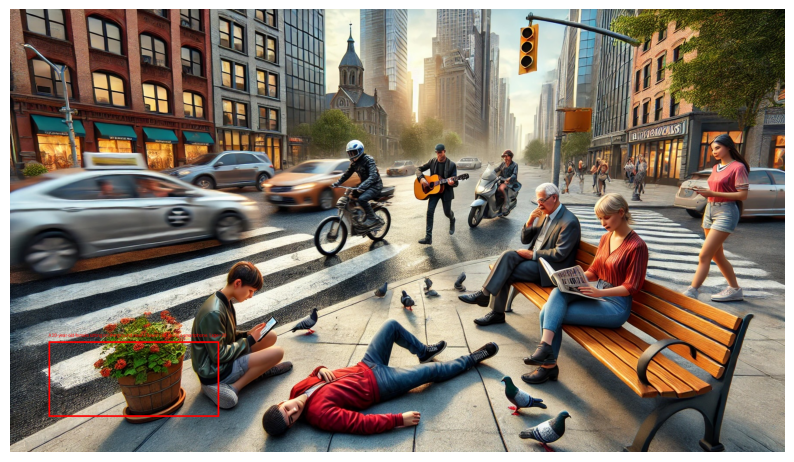

In [12]:
from PIL import ImageDraw, Image
import matplotlib.pyplot as plt

def visualize_detection(img_path, detection):
    img = Image.open(img_path).convert("RGB")
    width, height = img.size
    
    ymin, xmin, ymax, xmax = detection.box_2d

    x1 = int(xmin / 1000 * width)
    y1 = int(ymin / 1000 * height)
    x2 = int(xmax / 1000 * width)
    y2 = int(ymax / 1000 * height)

    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

    label = f"{detection.person_description} | age={detection.estimated_age}"
    draw.text((x1, max(0, y1 - 20)), label, fill="red")

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


visualize_detection(img, youngest_result)

# 2. Google VLM (Gemini)
This section demonstrates the use of Google's Vision Language Model, Gemini.
We explore basic text generation as well as image analysis capabilities and structured outputs.

**Reference Material**:
- https://ai.google.dev/gemini-api/docs/quickstart
- https://ai.google.dev/gemini-api/docs/text-generation
- https://ai.google.dev/gemini-api/docs/image-understanding
- https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [13]:
from dotenv import load_dotenv
from google import genai
from PIL import Image
import textwrap

import json


load_dotenv()
client = genai.Client()

# Path to your image
img = "images/street_scene.jpg"

Basic call:

In [14]:
response = client.models.generate_content(
    model="gemini-2.5-flash", contents="Explain how AI works to a 90-year-old in a few words."
)

print(textwrap.fill(response.text, width=120))

AI teaches computers to learn from lots of examples, just like a child learns. This lets them recognize things and make
smart guesses or helpful decisions.


And with images:

In [15]:
im = Image.open(img)

response = client.models.generate_content(model="gemini-2.5-flash",
                                          contents=[im, "Describe the scene in detail.\n"],
                                          )

print(textwrap.fill(response.text, width=120))

This vibrant urban scene captures a bustling city street during what appears to be the golden hour, with warm, soft
light bathing the buildings and casting long shadows. The perspective is from a low angle on a sidewalk, looking down a
long street lined with a mix of modern skyscrapers and older brick buildings.  **The Background and Street:** The
distant background features numerous tall, modern glass and steel skyscrapers, glowing softly in the warm light. Closer
in, older brick buildings with multiple windows and some dark storefronts line both sides of the street. On the left, a
multi-story building with reddish-brown brickwork and green awnings over its ground-floor windows is prominent. Further
down on the right, another brick building has a visible sign that reads "GREGORY'S." The street itself is wide, with
clearly marked black and white striped crosswalks. An amber traffic light hangs overhead, indicating caution or an
upcoming change.  **Vehicular and Pedestrian Movement:** T

We can also extract structured output (Gemini generally prefers Pydantic syntax).
Let's see how it behaves with a schema like before. See limitations: https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [16]:
from pydantic import BaseModel, Field
from typing import List, Literal

class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]

class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]
    
    
json_schema = ImageExtract.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": json_schema
}

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        im,
        "Describe the scene in detail and follow the given JSON schema exactly."
    ],
    config=config
)

print(response.text)

{
  "numberOfPeople": 8,
  "atmosphere": "A busy urban street scene with various activities taking place, including traffic, pedestrians, and street performers, bathed in the warm light of late afternoon.",
  "hourOfTheDay": 17,
  "people": [
    {
      "position": "Riding a motorcycle across the zebra crossing in the street.",
      "age": 30,
      "activity": "Riding a motorcycle.",
      "gender": "male"
    },
    {
      "position": "Walking on the zebra crossing in the street, to the right of the motorcyclist.",
      "age": 25,
      "activity": "Walking and playing an acoustic guitar.",
      "gender": "male"
    },
    {
      "position": "Riding a scooter on the street, behind the guitarist.",
      "age": 40,
      "activity": "Riding a scooter.",
      "gender": "female"
    },
    {
      "position": "Sitting on a wooden bench on the sidewalk, on the right side of the image.",
      "age": 65,
      "activity": "Sitting and seemingly contemplating or resting, with his ha

In [17]:
import json

data = json.loads(response.text)

result = ImageExtract(**data)

print(result)
print(result.people[0].activity)

numberOfPeople=8 atmosphere='A busy urban street scene with various activities taking place, including traffic, pedestrians, and street performers, bathed in the warm light of late afternoon.' hourOfTheDay=17 people=[Person(position='Riding a motorcycle across the zebra crossing in the street.', age=30, activity='Riding a motorcycle.', gender='male'), Person(position='Walking on the zebra crossing in the street, to the right of the motorcyclist.', age=25, activity='Walking and playing an acoustic guitar.', gender='male'), Person(position='Riding a scooter on the street, behind the guitarist.', age=40, activity='Riding a scooter.', gender='female'), Person(position='Sitting on a wooden bench on the sidewalk, on the right side of the image.', age=65, activity='Sitting and seemingly contemplating or resting, with his hand near his face.', gender='male'), Person(position='Sitting on a wooden bench on the sidewalk, next to the older man.', age=35, activity='Reading a newspaper or book.', ge

Does it match your schema?

Let's use Gemini to detect an object in the image and return its coordinates:

In [18]:
from pydantic import BaseModel, Field
from typing import List

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )

import json

schema = Box2DResult.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": schema
}

youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[img, youngest_prompt],
    config=config
)

data = json.loads(response.text)

result = Box2DResult(**data)

print(result)

person_description='A male person, estimated 14 years old, sitting on the sidewalk next to a potted plant, near the zebra crossing, and using a tablet device.' estimated_age=14 box_2d=[700, 300, 850, 400]


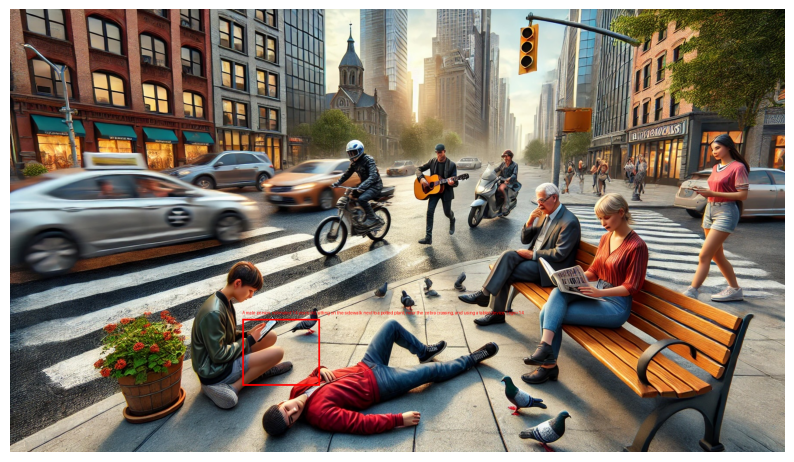

In [19]:
visualize_detection(img, result)

Gemini 2+ was trained specifically for object detection and segmentation tasks.

More details: https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb

## 3. Extract Structured Information from a Handwritten Note - GPT & Gemini

Let's extract structured information from a handwritten note (e.g., `prescription1.jpg`) using both models.

Consider the file: `/images/prescription1.jpg`.
Take a look at it.

### JSON Schema
Let's define a JSON schema for the extraction task:

In [21]:
json_schema_prescription = {
 "name": "prescription_extract",
"schema": {
  "type": "object",
  "properties": {
    "doctor_name": { "type": "string" },
    "patient_name": { "type": "string" },
    "patient_dob": { "type": "string" },
    "meds": {
      "type": "array",
      "items": {
        "type": "object",
        "properties": {
          "name": { "type": "string" },
          "dose": { "type": "string" },
          "frequency": { "type": "string" },
          "instructions": { "type": "string" }
        },
        "required": ["name"]
      }
    },
    "signature": { "type": "boolean" }
  },
  "required": ["doctor_name", "patient_name", "meds"]
}}

## TODO
- Extract once with OpenAI and once with Google Gemini using Pydantic validation (https://docs.pydantic.dev/latest/).

Extract structured information using Gemini:

In [22]:
from pydantic import BaseModel, Field
from typing import List
import json

class Medication(BaseModel):
    name: str
    dose: str = ""
    frequency: str = ""
    instructions: str = ""

class PrescriptionExtract(BaseModel):
    doctor_name: str
    patient_name: str
    patient_dob: str = ""
    meds: List[Medication]
    signature: bool = False

im = Image.open("images/prescription1.jpg")

# Generate the JSON schema from the Pydantic model
schema = PrescriptionExtract.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": schema
}

# API call with Gemini
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        im,
        "Extract all information from this prescription following the JSON schema exactly. "
        "Include doctor name, patient name, date of birth, all medications with doses and frequency, "
        "and whether a signature is present."
    ],
    config=config
)

# Ergebnis als Pydantic-Objekt laden
gemini_data = json.loads(response.text)
gemini_result = PrescriptionExtract(**gemini_data)

print("Gemini Extraction Result:")
print(gemini_result.model_dump_json(indent=2))


Gemini Extraction Result:
{
  "doctor_name": "Dr. Markus Müller",
  "patient_name": "Claudie Fischer",
  "patient_dob": "1.4.1978",
  "meds": [
    {
      "name": "Ibuprofen",
      "dose": "400mg",
      "frequency": "3x",
      "instructions": "nach dem Essen"
    }
  ],
  "signature": true
}


Now let's do the same with GPT.

In [23]:
# Extract using OpenAI
gpt_response = openai_client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Extract all information from this prescription following the schema exactly. "
                    "Include doctor name, patient name, date of birth, all medications with doses and frequency, "
                    "and whether a signature is present."
                },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image('images/prescription1.jpg')}"
                }
            ],
        }
    ],
    text_format=PrescriptionExtract,
)

gpt_result = gpt_response.output_parsed

print("OpenAI GPT Extraction Result:")
print(gpt_result.model_dump_json(indent=2))

OpenAI GPT Extraction Result:
{
  "doctor_name": "Dr. Markus Müller",
  "patient_name": "Claudia Fischer",
  "patient_dob": "1.4.1978",
  "meds": [
    {
      "name": "Ibuprofen",
      "dose": "400 mg",
      "frequency": "3x",
      "instructions": "nach dem Essen"
    }
  ],
  "signature": true
}


Any differences between the Gemini and OpenAI outputs?